✅ Random Forest Results
Accuracy: 0.6841844323252355

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.68      0.80      7482
           1       0.15      0.73      0.25       586

    accuracy                           0.68      8068
   macro avg       0.56      0.71      0.53      8068
weighted avg       0.91      0.68      0.76      8068



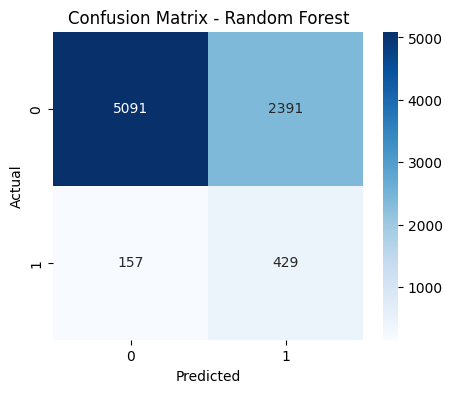

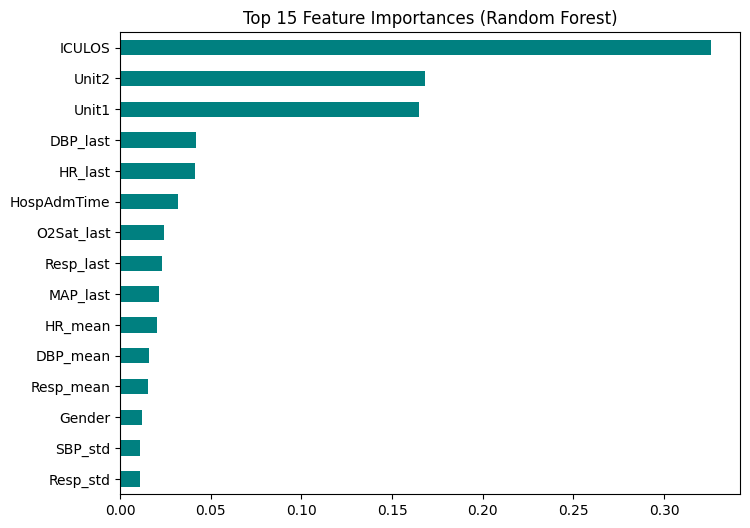

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Read saved data ---
train_data = pd.read_csv("../../data/raw/processed_data/train_resampled.csv")
test_data  = pd.read_csv("../../data/raw/processed_data/test_data.csv")

# --- 2️⃣ Split features and target ---
X_train = train_data.drop(columns=['SepsisLabel'])
y_train = train_data['SepsisLabel']

X_test = test_data.drop(columns=['SepsisLabel'])
y_test = test_data['SepsisLabel']

# --- 3️⃣ Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4️⃣ Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf.fit(X_train_scaled, y_train)

# --- 5️⃣ Predict and evaluate ---
y_pred = rf.predict(X_test_scaled)

print("✅ Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6️⃣ Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# --- 7️⃣ Feature importance ---
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances[:15].plot(kind='barh', color='teal')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


✅ Decision Tree Results
Accuracy: 0.9201784828953892

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96      7482
           1       0.46      0.62      0.53       586

    accuracy                           0.92      8068
   macro avg       0.72      0.78      0.74      8068
weighted avg       0.93      0.92      0.93      8068



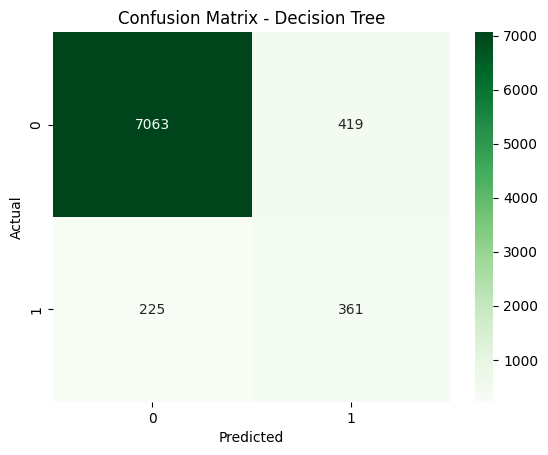

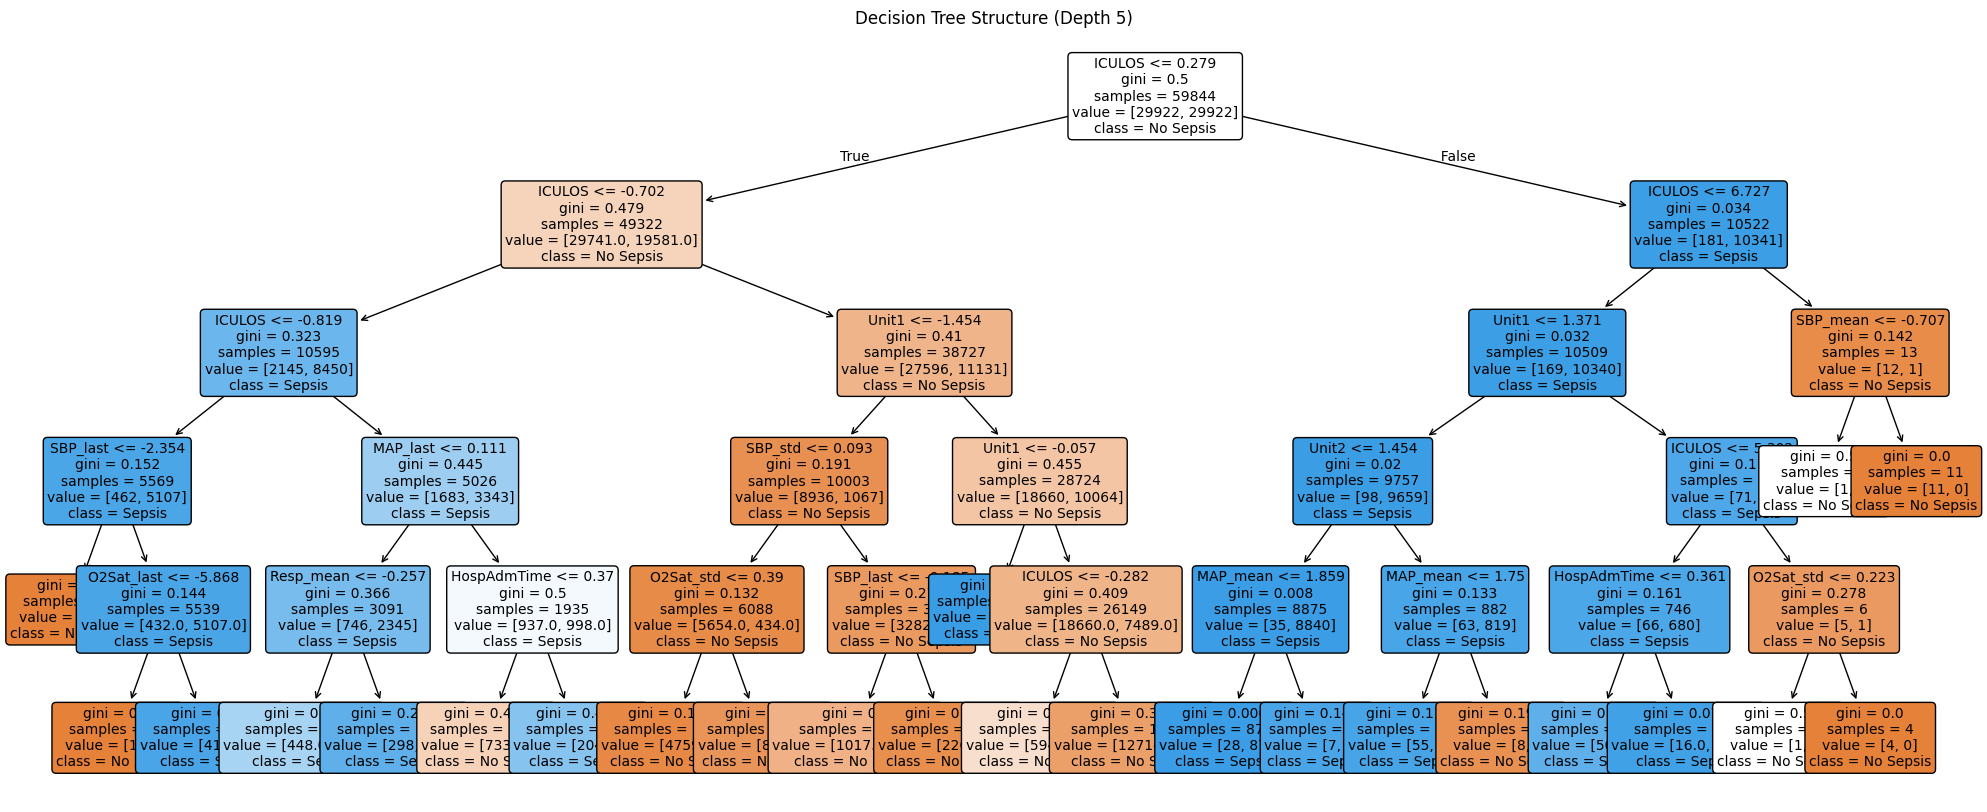

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Initialize Decision Tree ---
dt = DecisionTreeClassifier(
    max_depth=5,          # limit depth so it's easier to visualize
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# --- 2️⃣ Train ---
dt.fit(X_train_scaled, y_train)

# --- 3️⃣ Predict ---
y_pred_dt = dt.predict(X_test_scaled)

# --- 4️⃣ Evaluate ---
print("✅ Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# --- 5️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# --- 6️⃣ Visualize the Tree ---
plt.figure(figsize=(25, 10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=['No Sepsis', 'Sepsis'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure (Depth 5)")
plt.show()


In [7]:
print("Train Accuracy:", dt.score(X_train_scaled, y_train))
print("Test Accuracy:", dt.score(X_test_scaled, y_test))


Train Accuracy: 0.8236080475904017
Test Accuracy: 0.9201784828953892


✅ Random Forest + ExtraTrees (Jugadd Ensemble) Results
Accuracy: 0.8006941001487358

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.88      7482
           1       0.21      0.64      0.32       586

    accuracy                           0.80      8068
   macro avg       0.59      0.73      0.60      8068
weighted avg       0.91      0.80      0.84      8068



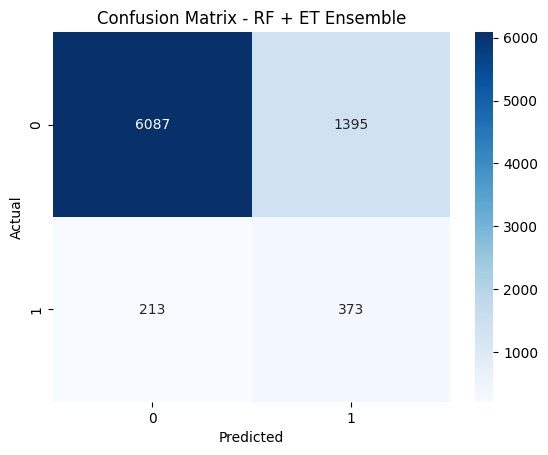

In [ ]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1️⃣ Individual models ---
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

et = ExtraTreesClassifier(  # very similar to RF but more random
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

# --- 2️⃣ Combine both ("Jugadd Forest of Forests") ---
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('et', et)],
    voting='soft',   # average probabilities
    n_jobs=-1
)

# --- 3️⃣ Train ---
ensemble.fit(X_train_scaled, y_train)

# --- 4️⃣ Predict ---
y_pred = ensemble.predict(X_test_scaled)

# --- 5️⃣ Evaluate ---
print("✅ Random Forest + ExtraTrees (Jugadd Ensemble) Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RF + ET Ensemble")
plt.show()
